#### 로지스틱 회귀로 와인 분류하기

In [90]:
import pandas as pd

In [91]:
wine = pd.read_csv("../Data/wine.csv")
wine.head()

,alcohol,sugar,pH,class
0,9.4,1.9,3.51,0.0
1,9.8,2.6,3.20,0.0
2,9.8,2.3,3.26,0.0
3,9.8,1.9,3.16,0.0
4,9.4,1.9,3.51,0.0


In [92]:
wine.tail()

,alcohol,sugar,pH,class
6492,11.2,1.6,3.27,1.0
6493,9.6,8.0,3.15,1.0
6494,9.4,1.2,2.99,1.0
6495,12.8,1.1,3.34,1.0
6496,11.8,0.8,3.26,1.0


In [93]:
# class의 종류 파악
# wine['class'].unique()
wine['class'].value_counts()

class
1.0    4898
0.0    1599
Name: count, dtype: int64

> 0: Red Wine, 1: White Wine

In [94]:
wine.info()

<class 'pandas.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   alcohol  6497 non-null   float64
 1   sugar    6497 non-null   float64
 2   pH       6497 non-null   float64
 3   class    6497 non-null   float64
dtypes: float64(4)
memory usage: 203.2 KB


In [95]:
wine.shape

(6497, 4)

In [96]:
# 기본 통계량
wine.describe()

,alcohol,sugar,pH,class
count,6497.000000,6497.000000,6497.000000,6497.000000
mean,10.491801,5.443235,3.218501,0.753886
std,1.192712,4.757804,0.160787,0.430779
min,8.000000,0.600000,2.720000,0.000000
25%,9.500000,1.800000,3.110000,1.000000
50%,10.300000,3.000000,3.210000,1.000000
75%,11.300000,8.100000,3.320000,1.000000
max,14.900000,65.800000,4.010000,1.000000


#### Feature와 Target

In [97]:
data = wine[['alcohol','sugar','pH']].to_numpy()
target = wine['class'].to_numpy()
data[:5]

array([[9.4 , 1.9 , 3.51],
       [9.8 , 2.6 , 3.2 ],
       [9.8 , 2.3 , 3.26],
       [9.8 , 1.9 , 3.16],
       [9.4 , 1.9 , 3.51]])

In [98]:
target[:5]

array([0., 0., 0., 0., 0.])

----
#### Train과 Test

In [99]:
from sklearn.model_selection import train_test_split

In [100]:
train_input, test_input, train_target, test_target = \
   train_test_split(
      data,
      target,
      test_size=0.2,
      random_state=42
   )

In [101]:
print("Train :", train_input.shape)
print("Test :", test_input.shape)

Train : (5197, 3)
Test : (1300, 3)


#### 로지스틱 회귀이므로 표준화하기

In [102]:
from sklearn.preprocessing import StandardScaler

In [103]:
ss = StandardScaler()
ss.fit(train_input)
train_scaled = ss.transform(train_input)
test_scaled = ss.transform(test_input)

#### 로지스틱 회귀 모델
: 로지스틱의 경우 Class~는 없음

In [104]:
from sklearn.linear_model import LogisticRegression

In [105]:
lr = LogisticRegression()
lr.fit(train_scaled,train_target)
print("Train :", lr.score(train_scaled,train_target))
print("Test :", lr.score(test_scaled,test_target))

Train : 0.7808350971714451
Test : 0.7776923076923077


In [106]:
# 가중치와 편차 구하기
print(lr.coef_, lr.intercept_)

[[ 0.51268071  1.67335441 -0.68775646]] [1.81773456]


In [107]:
train_scaled

array([[ 0.01376574,  0.4646116 , -0.16888369],
       [ 1.60871671, -0.70299854,  0.26967864],
       [ 1.10504798, -0.70299854,  1.20945505],
       ...,
       [-0.82568214,  0.0267578 ,  0.14437512],
       [-0.82568214,  0.52716215, -0.23153545],
       [-0.82568214, -0.57789745,  1.83597265]], shape=(5197, 3))

In [108]:
# lr.classes_
# class = 0.51268071 * alcohol + 1.67335441 * sugar + -0.68775646 * ph + 1.81773456

----
#### 결정트리(Decision Tree)
: 선형회귀나 kNN처럼 전처리 과정이 필요없다.

#### Decision Tree를 이용한 모델의 생성

In [109]:
from sklearn.tree import DecisionTreeClassifier

In [110]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(train_input,train_target)
print("Train :", dt.score(train_input,train_target))
print("Test :", dt.score(test_input,test_target))

Train : 0.996921300750433
Test : 0.8584615384615385


#### 시각화

In [111]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

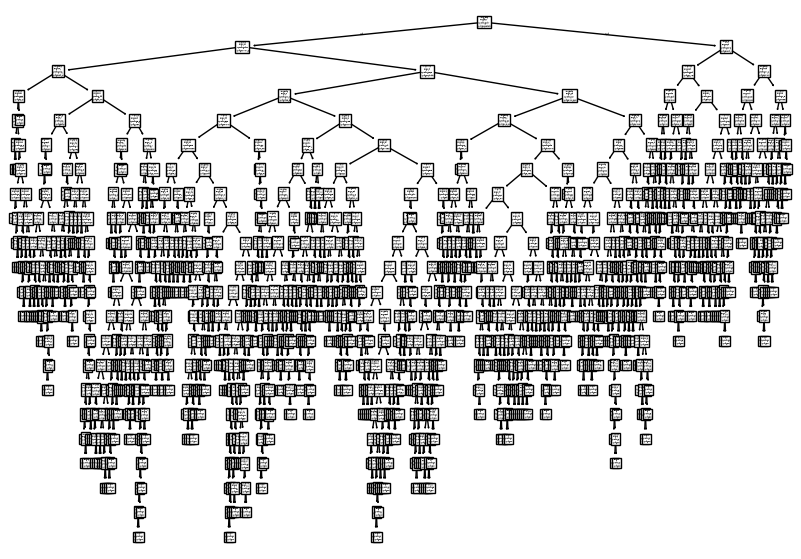

In [112]:
plt.figure(figsize=(10,7))
plot_tree(dt) # 모델 이름인 dt를 이용하여 시각화
plt.show()

> 맨 위의 단계를 root node라고 하고 맨 마지막 단계는 leaf_node라고 한다.
시간이 너무 많이 걸리고 단계가 너무 복잡하다.

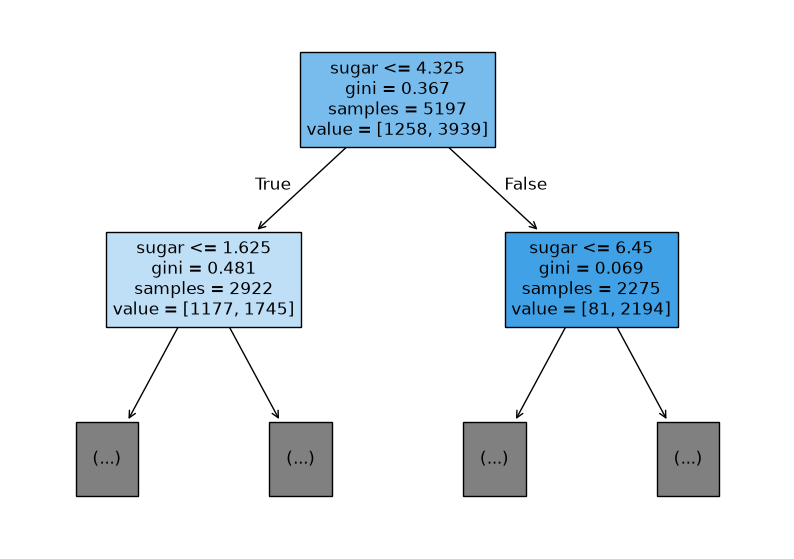

In [113]:
# decision tree의 단계(depth)를 단순하게 하자
plt.figure(figsize=(10,7))
plot_tree(
   dt,
   max_depth=1,
   filled=True,
   feature_names=['alcohol','sugar','pH']
)
plt.show()

## 색이 진할수록 양성(1) 연할수록(0)

> 양성(1)일수록 파란색으로 표시.

> 음성(0)일수록 색이 점점 연해지며 최종적으로는 빨간색으로 표시된다.

- root node에서 sugar <= 4.325이면 왼쪽으로 이동하고 아니면 오른쪽으로 이동한다.
- 총 갯수가 5197개인데 ture인 노드는 2922개, false인 노드는 2275개이다.

- 지니 불순도(gini Impurity)가 0이 나올 때를 순수노드 라고 한다.
-> leaf node가 순수 노드인것은 좋으나 이때 과대적합이 발생한다.

- 따라서 적절한 max_depth를 찾는것이 중요하다.

#### 가지치기(Tree Pruning)

- max_depth의 parameter값을 조절.
- Decision Tree의 과대적합을 막는다.
- 선형회귀처럼 규제를 사용할 수 없다.

In [114]:
dt = DecisionTreeClassifier(
   max_depth=3
)
dt.fit(train_input,train_target)
print("Train:", dt.score(train_input, train_target))
print("Test:", dt.score(test_input, test_target))

# for문을 이용해 max_depth의 값을 찾는게 더 좋다

Train: 0.8454877814123533
Test: 0.8415384615384616


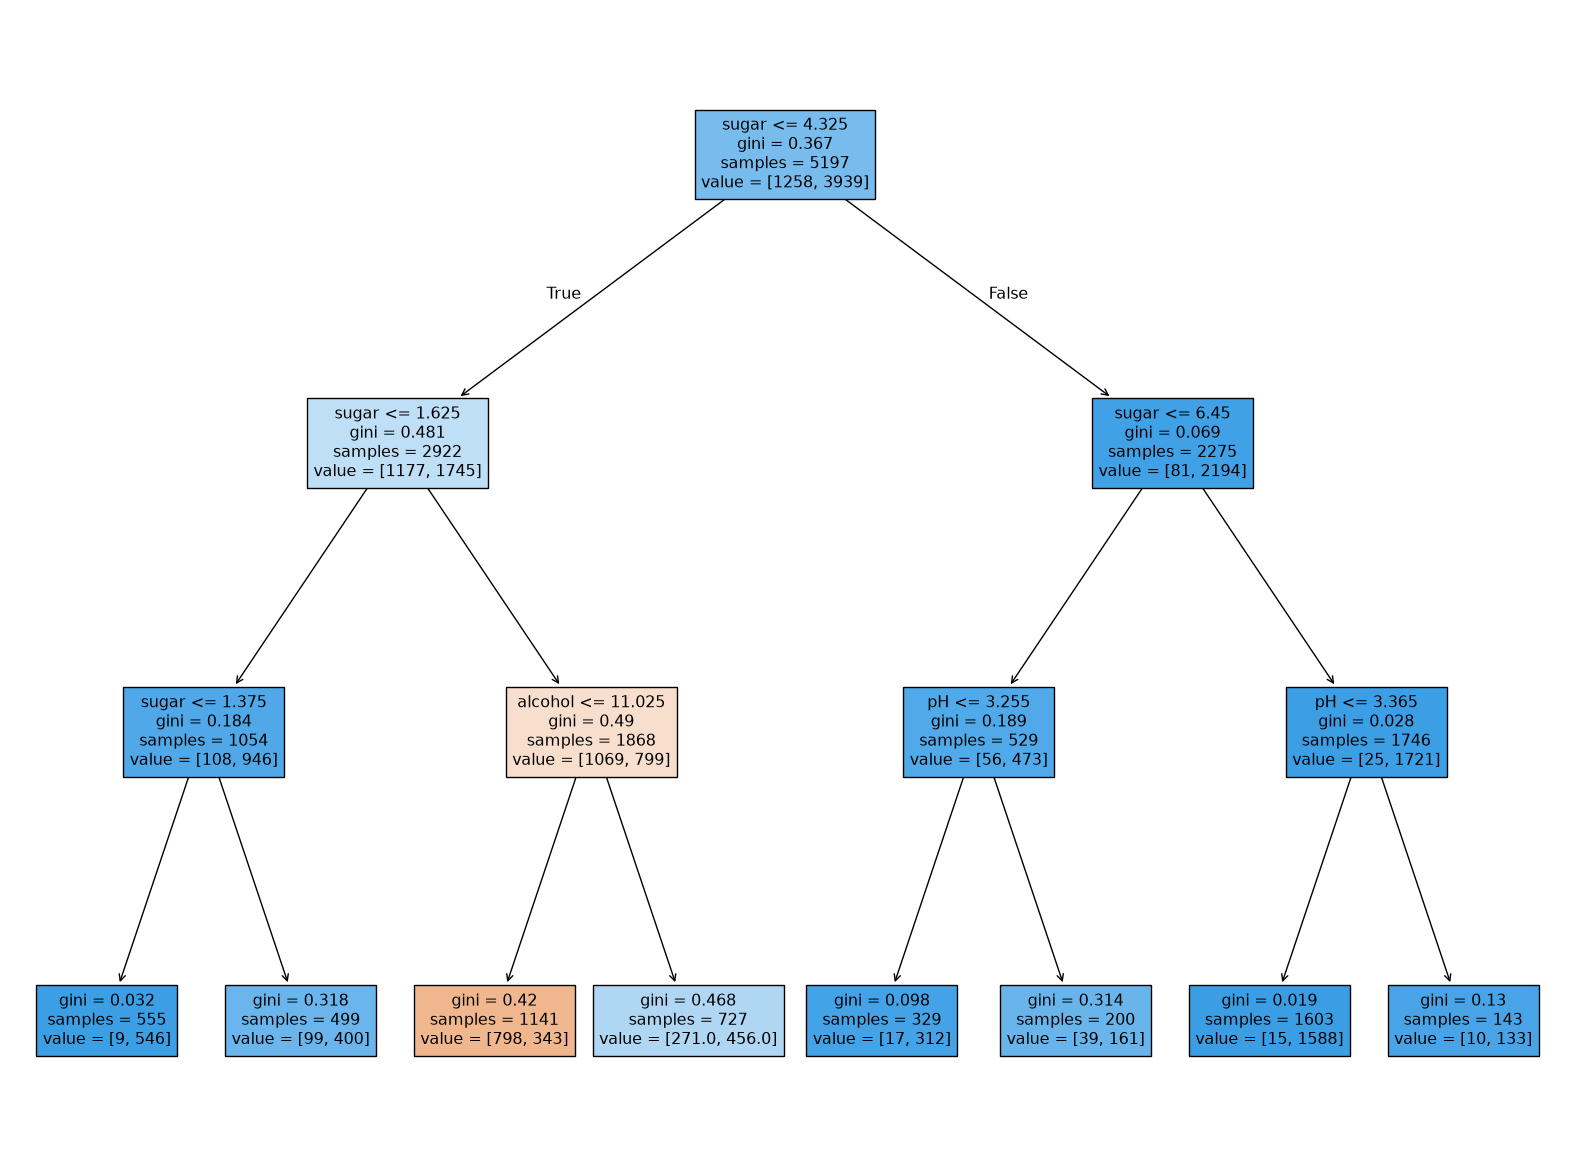

In [115]:
plt.figure(figsize=(20,15))
plot_tree(
   dt,
   filled=True,
   feature_names=['alcohol','sugar','pH']
)
plt.show()

## 색이 진할수록 양성(1) 연할수록(0)

In [116]:
# 특성 중요도
dt.feature_importances_
# 순서대로 알코올, 슈가, pH의 순서임

array([0.12345626, 0.86862934, 0.0079144 ])

> alcohol, sugar, pH의 순으로 특성 중요도가 출력되며, 이 중 sugar가 제일 중요한 요소로 작동된다는 것을 알 수 있다.

#### 최적화 시키기

In [119]:
dt = DecisionTreeClassifier(
   min_impurity_decrease=0.0005
   # 노드를 분할하는 기준인 최소 불순도를 0.05%로 설정
)

dt.fit(train_input,train_target)
print("Train:", dt.score(train_input, train_target))
print("Test:", dt.score(test_input, test_target))

Train: 0.8874350586877044
Test: 0.8615384615384616


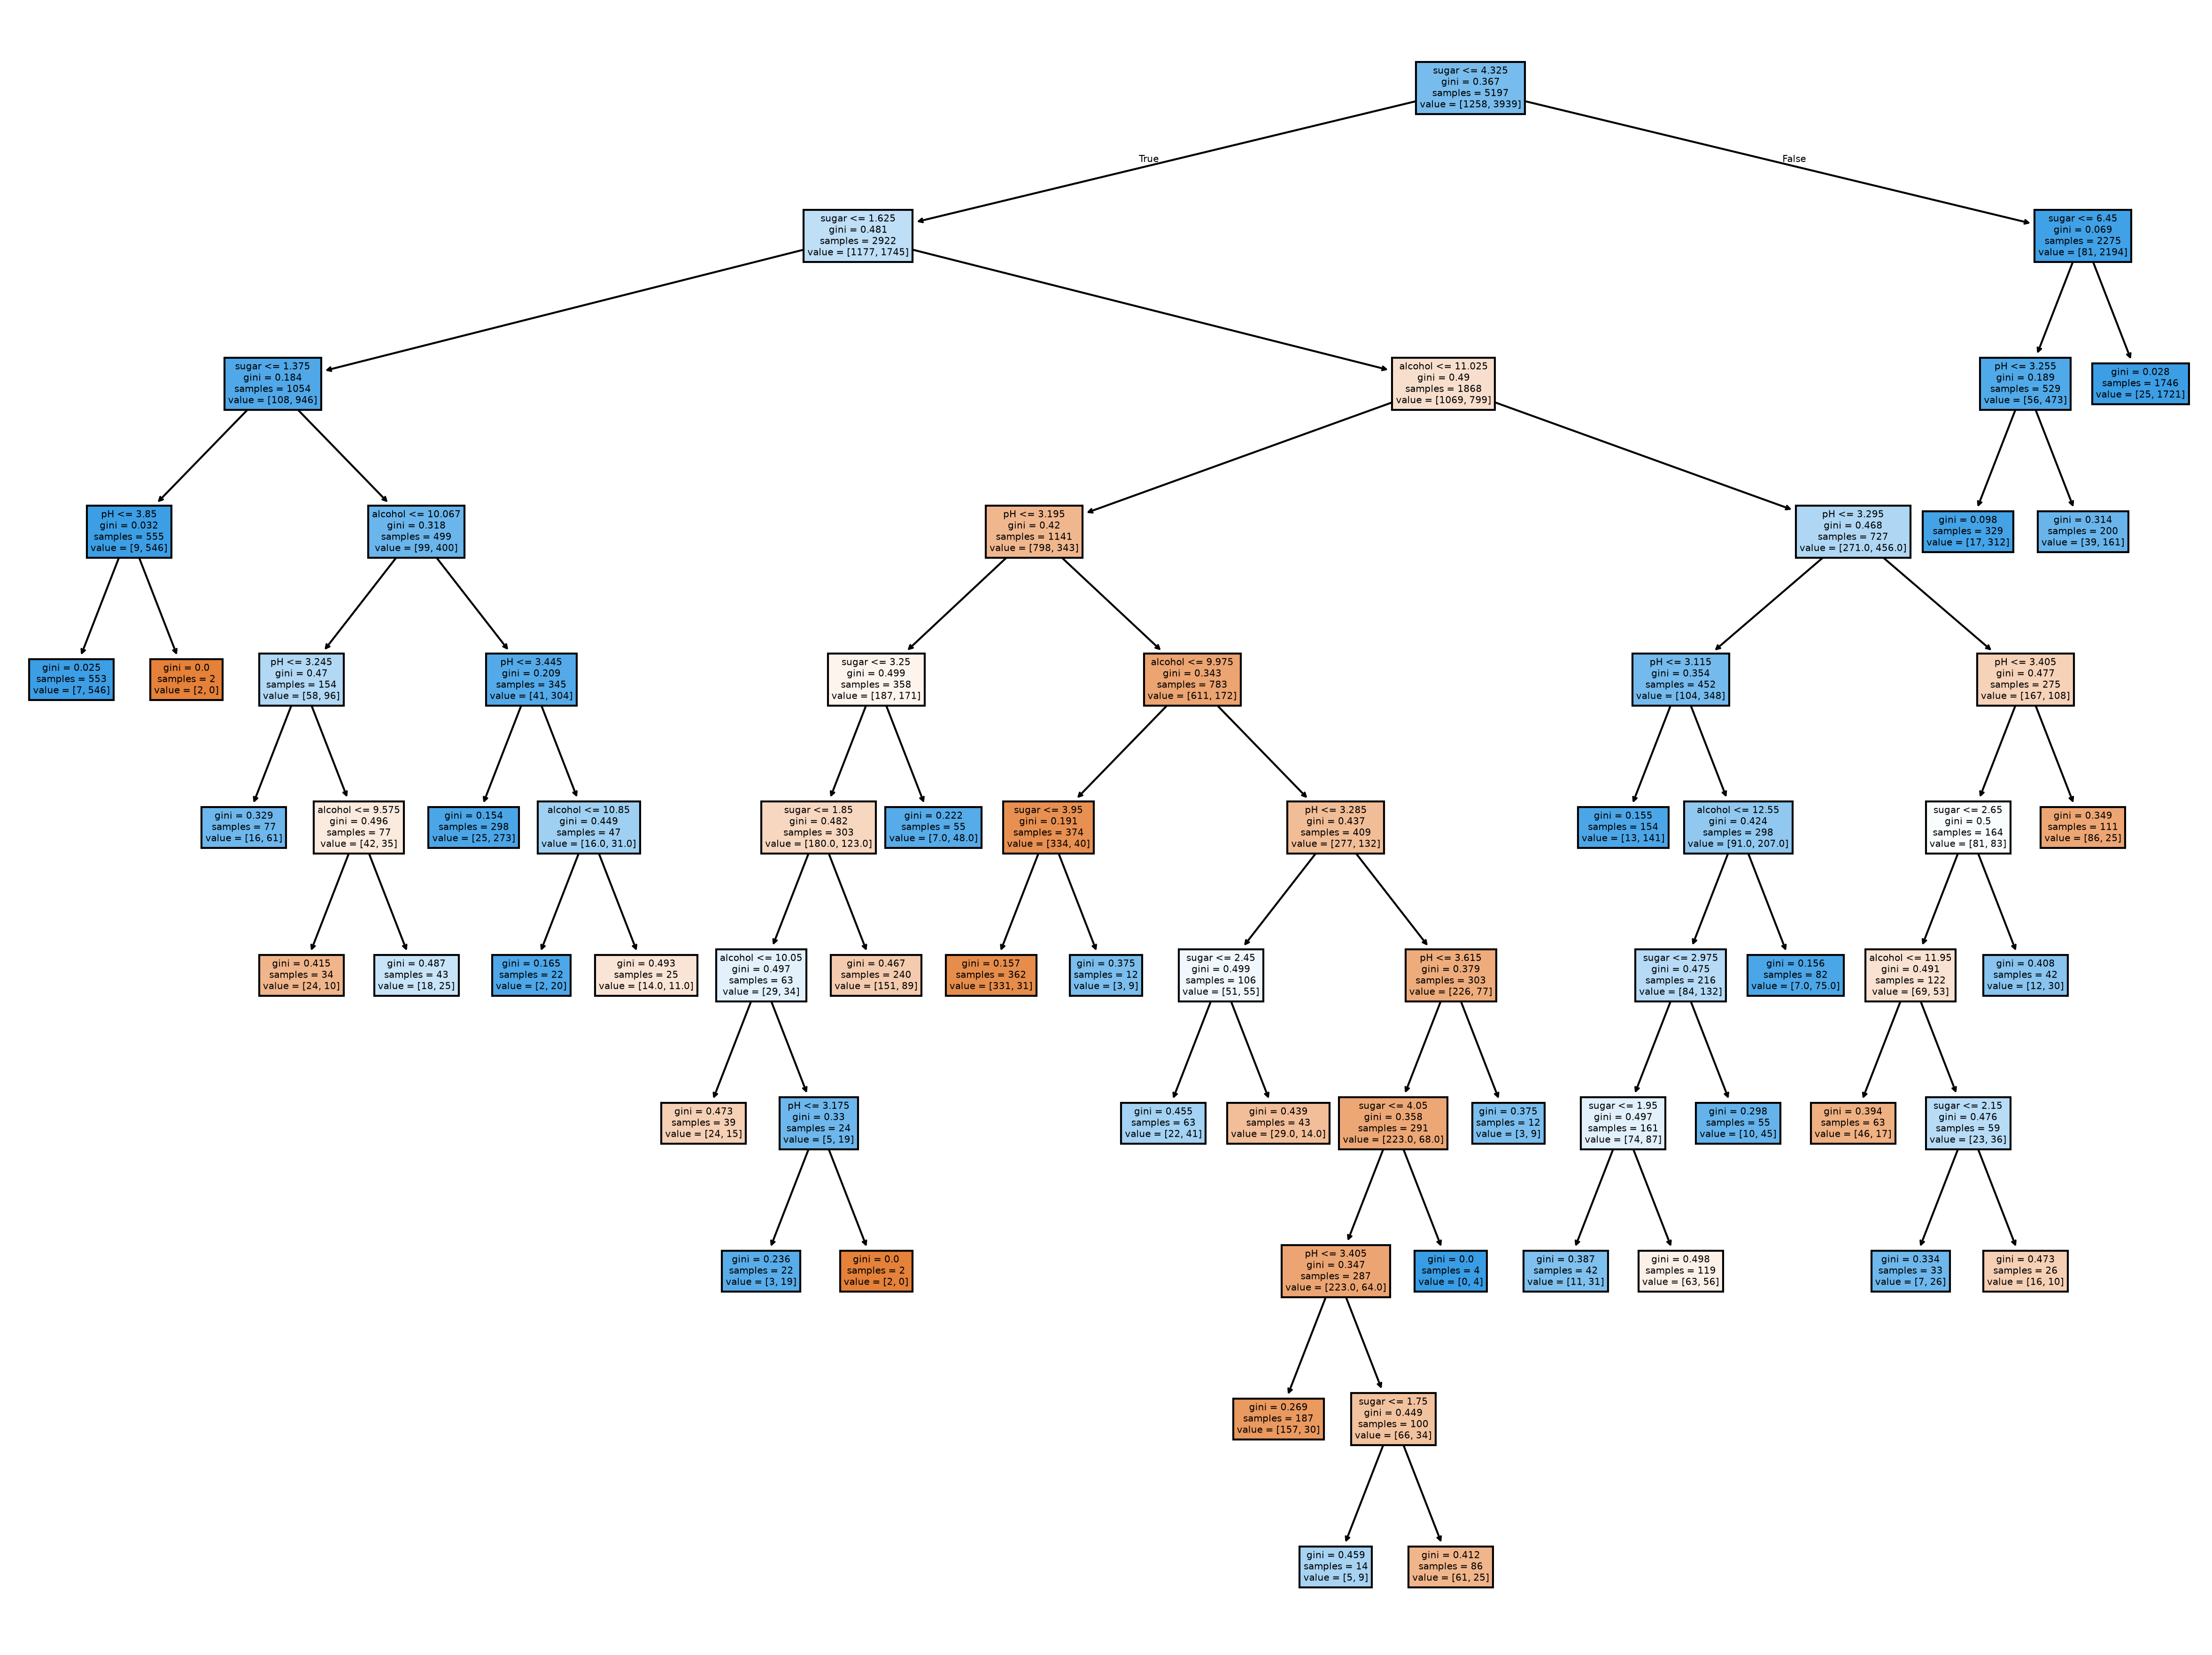

In [120]:
plt.figure(figsize=(20,15),dpi=300)
plot_tree(
   dt,
   filled=True,
   feature_names=['alcohol','sugar','pH']
)
plt.savefig("../Data/wine.jpg") # 해상도를 높이는 코드. 반드시 show전에 사용해야 함
plt.show()
